# Basic signals
Nesta atividades criaremos a nossa primeira **biblioteca de sinais digitais** com os sinais:

1. Delta: $\delta[n]$
2. Degrau: $u[n]$
3. Oscilação (periódico): $A \sin(\omega n + \phi)$
4. Exponencial
5. Aleatório (estocástico)


## Sinal delta, ou "impulso" - $\delta[n]$

<div style="text-align: center;">
    <img src="./figures/delta.png" alt="" width="500"/>
</div>


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# import sys
# sys.path.append('/home/kuntur/Documents')
# from lib.myPlotLib import *

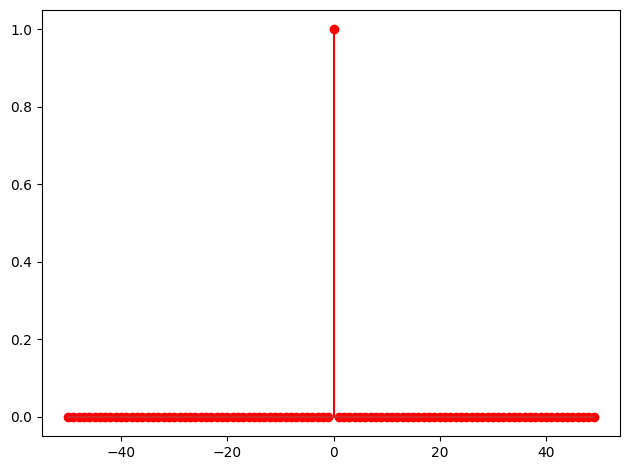

In [25]:
# 1. Sinal delta (v1.0) - Usando numpy
N     = 100
xn    = np.zeros(N)
k     = 50 # delay)
xn[k] = 1 # x[n-k]

# v2.0 - Usando listas
xn    = [0]*N
xn[k] = 1
xn    = np.array(xn)

# Vetor de amostras
n     = np.arange(-50, 50)


fig, ax = plt.subplots()
ax.stem(n, xn, 'r')
fig.tight_layout()
plt.show()

## Sinal degrau - $u[n]$

<div style="text-align: center;">
    <img src="./figures/step.png" alt="" width="500"/>
</div>


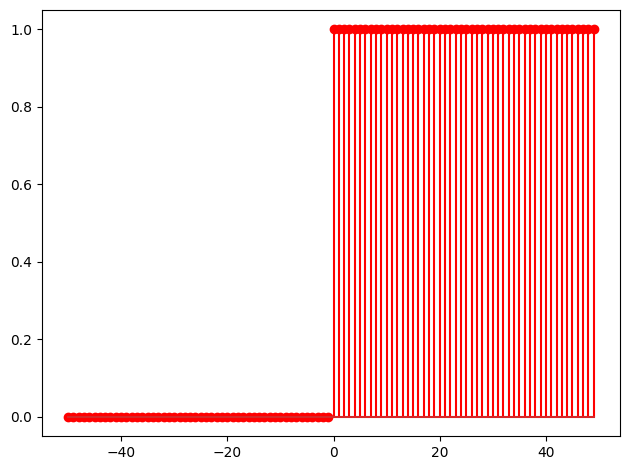

In [26]:
# 2. Degrau (v1.0) - Usando numpy
N     = 100
un        = np.zeros(N)
un[k:] = 1

# v2.0 - Usando listas
un = [0]*k + [1]*(N-k)
un = np.array(un)

# Vetor de amostras
n  = np.arange(-50, 50)

fig, ax = plt.subplots()
ax.stem(n, un, 'r')
fig.tight_layout()
plt.show()

## Sinal oscilatório, ou periódico - $A \sin(\omega n + \phi)$

<div style="text-align: center;">
    <img src="./figures/sine.png" alt="" width="500"/>
</div>


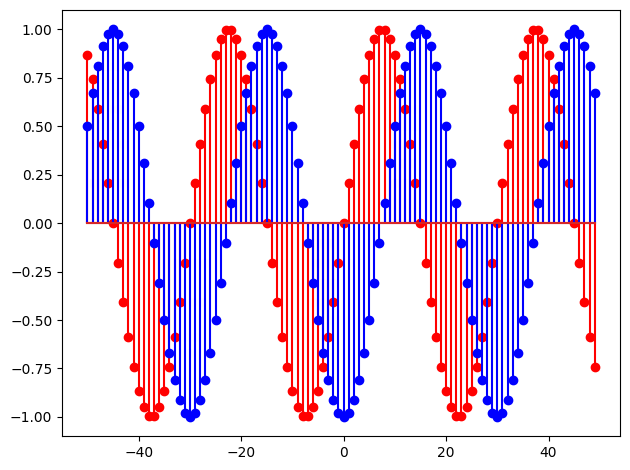

In [33]:
# 4. Sinal periodico
N  = 100
k  = 0 # delay
n  = np.arange(-50,50) # vetor de amostras

A   = 1
P   = 30 # periodo do sinal
wo  = 2*np.pi/P # frequencia digital
phi = 0 # fase
xn  = A * np.sin(wo * n + phi)
yn  = A * np.sin(wo * n + phi + 3*np.pi/2)

# Plotagem
fig, ax = plt.subplots()
ax.stem(n, xn, 'ro')
ax.stem(n, yn, 'bd')
#plt.xlim([0, 30])
fig.tight_layout()
plt.show()

## Sinal exponencial - $|a|^{n} u[n]$

<div style="text-align: center;">
    <img src="./figures/exp.png" alt="" width="500"/>
</div>


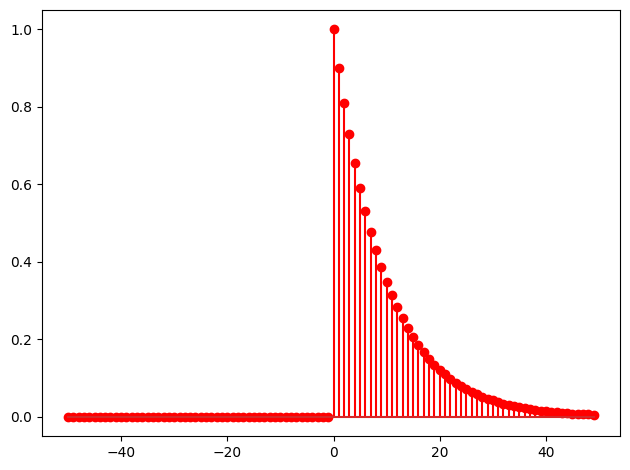

In [36]:
# 3. Exponencial
a  = 0.9
yn = (a**n) *un

fig, ax = plt.subplots()
ax.stem(n, yn, 'r')
fig.tight_layout()
plt.show()

## Sinal aleatório - $x[n] = ?$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian.png" alt="" width="500"/>
    <img src="./figures/random-uniform.png" alt="" width="500"/>
</div>


### Aleatório Gaussiano - $\mathcal{X} \sim \mathcal{N}(\mu, \sigma)$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian-dist.png" alt="" width="500"/>
</div>


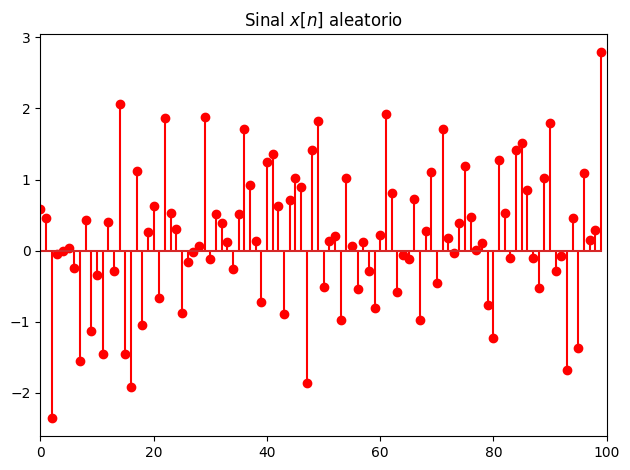

In [42]:
# 5. Sinal aleatorio (distribuicao Gaussiana)
N = 100
n  = np.arange(N) # vetor de amostras

xn = np.random.normal(0,1, N) # Gaussiano (normal)

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
fig.tight_layout()
plt.show()

Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`


In [ ]:
# help(ax.hist)

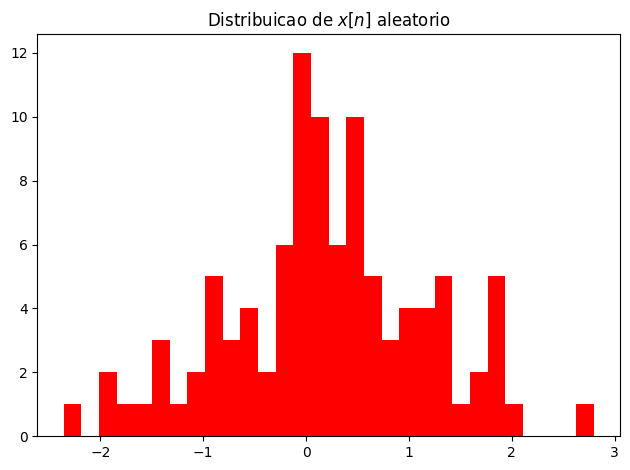

In [43]:
fig, ax = plt.subplots()
ax.hist(xn, 30, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
fig.tight_layout()
plt.show()

### Aleatório uniforme - $\mathcal{X} \sim \mathcal{U} \{a, b\}$

<div style="text-align: center;">
    <img src="./figures/random-uniform-dist.png" alt="" width="500"/>
</div>


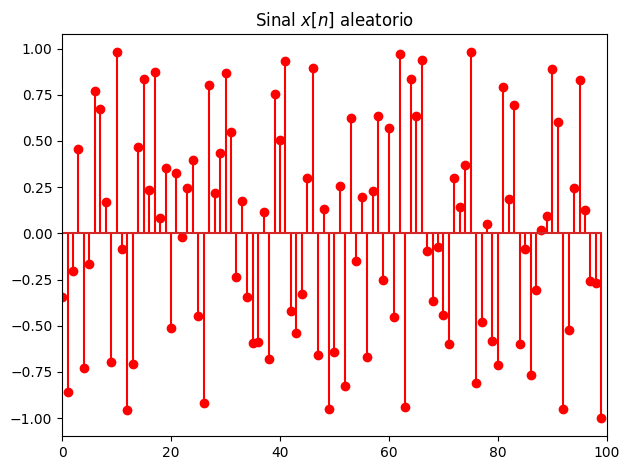

In [46]:
# 5. Sinal aleatorio (distribuicao uniforme)
N = 100
n  = np.arange(N) # vetor de amostras

xn = np.random.uniform(-1, 1, N) # uniforme

# Plot
fig, ax = plt.subplots(1)
ax.stem(n, xn, 'ro')
plt.xlim([0, 100])
ax.set_title(r'Sinal $x[n]$ aleatorio')
fig.tight_layout()
plt.show()

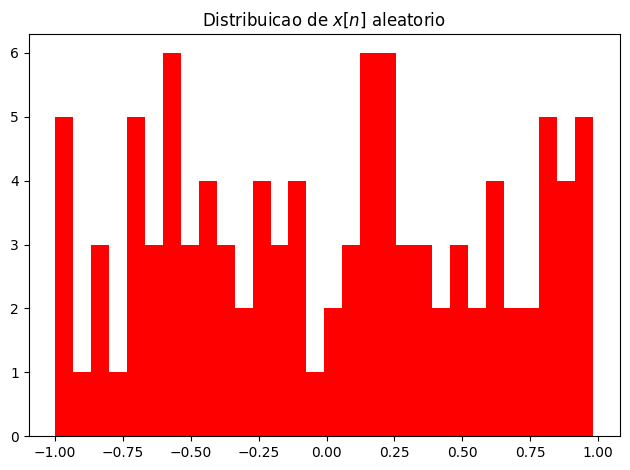

In [47]:
fig, ax = plt.subplots()
ax.hist(xn, 30, color='r')
ax.set_title(r'Distribuicao de $x[n]$ aleatorio')
fig.tight_layout()
plt.show()

## Minha biblioteca de sinais básicos

In [48]:
def SIGNALgenerate(N=100, signal='delta', params=None):
    n=np.arange(N)

    if signal == 'delta':
      k = params if params is not None else 0
      x = np.zeros(N)
      if 0 <= k < N:
        x[k] = 1

    if signal == 'step':
        k = params if params is not None else 0
        x = np.zeros(N)
        if 0 <= k < N:
          x[k:] = 1

    if signal == 'exp':
      a = params.get('a', 0.9) if isinstance(params, dict) else 0.9
      k = params.get('k', 0) if isinstance(params, dict) else 0
      x = np.zeros(N)
      x[k:] = a**(n[k:] - k)


    if signal == 'osc':
      P   = params.get('P', 10) if isinstance(params, dict) else 10
      phi = params.get('phi', 0) if isinstance(params, dict) else 0
      wo  = 2*np.pi/P
      x = np.sin(wo*n + phi)

    if signal == 'random':

        if params == 'uniform':
            x = np.random.uniform(-1, 1, N)
        else:
            x = np.random.normal(0, 1, N)

    return np.array(x)


In [49]:
def SIGNALdelay(x, n):
    '''
    Slows a signal down by k samples
    '''
    result = np.zeros(len(x))
    result[n:] = x[:len(x) - n]

    return result


In [52]:
def SIGNALplot(x):
    fig, ax = plt.subplots()
    ax.stem(x, 'r')
    # figureFormat(ax, fig, tight=True)
    plt.show()


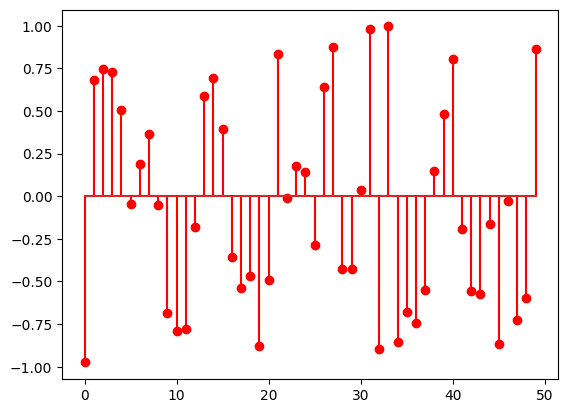

In [53]:
# Testando a biblioteca
SIGNALplot(SIGNALgenerate(50, 'random', 'uniform'))

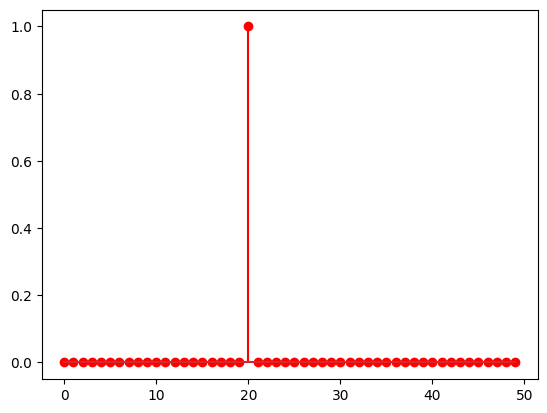

In [56]:
SIGNALplot(SIGNALgenerate(50, 'delta', 20))

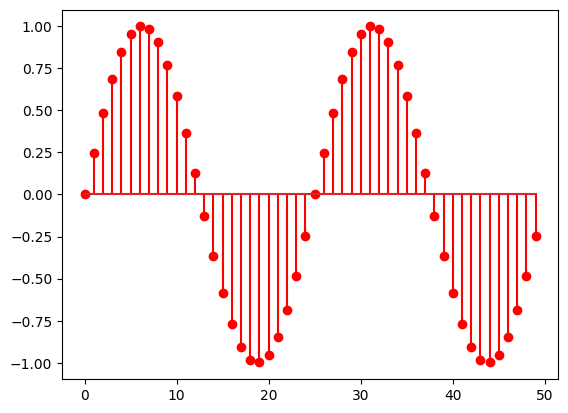

In [57]:
SIGNALplot((SIGNALgenerate(50, 'osc', {'P':25})))

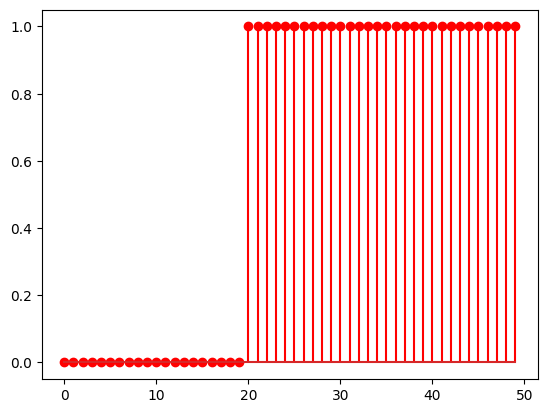

In [58]:
SIGNALplot(SIGNALgenerate(50, 'step', 20))

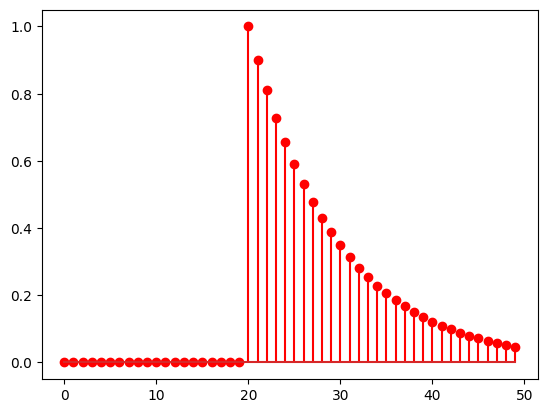

In [59]:
SIGNALplot(SIGNALgenerate(50, 'exp', {'a':0.9, 'k':20}))